# Cruise Fuel Prediction using XGBoost

Goal:
Predict fuel consumption during the cruise phase using ADS-B derived flight phase features.


### Imports


In [1]:
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt


### Load feature dataset

The cruise-phase feature table is loaded from the SQLite database.
Each row represents one flight with aggregated phase-level features.

Target variable:
- cruise_fuel

Input features:
- `alt_gain_m_cruise`: altitude gained during cruise
- `time_s_cruise`: cruise duration
- `dist_m_cruise`: distance flown during cruise
- `alt_loss_m_cruise`: altitude lost during cruise
- `mean_alt_m_cruise`: mean altitude during cruise
- `max_alt_m_cruise`: maximum altitude during cruise
- `mean_vr_mps_cruise`: mean vertical rate during cruise
- `mean_gs_mps_cruise`: mean ground speed during cruise
- `p95_gs_mps_cruise`: 95th percentile ground speed during cruise
- `std_gs_mps_cruise`: ground speed variability during cruise
- `p95_abs_vr_mps_cruise`: 95th percentile absolute vertical rate during cruise
- `turn_sum_deg_cruise`: cumulative heading change during cruise
- `great_circle_distance`: route distance between departure and arrival airports
- `n_points_cruise`: number of ADS-B observations assigned to cruise

These ADS-B derived features describe the cruise-phase trajectory, altitude profile, speed profile, vertical motion, turning behavior, route length, and observation coverage.


In [2]:
DB_PATH = "../../opensky.sqlite"
FEATURE_TABLE = "flight_phase_features_new_phase"

YEAR = 2022

TARGET = "cruise_fuel"


FEATURES = [
    "alt_gain_m_cruise",
    "time_s_cruise",
    "dist_m_cruise",
    "alt_loss_m_cruise",
    "mean_alt_m_cruise",
    "max_alt_m_cruise",
    "mean_vr_mps_cruise",
    "mean_gs_mps_cruise",
    "p95_gs_mps_cruise",
    "std_gs_mps_cruise",
    "p95_abs_vr_mps_cruise",
    "turn_sum_deg_cruise",
    "great_circle_distance",
    "n_points_cruise"

]

### Reconstruct Flight Datetime

The dataset does not contain an explicit `flight_dt` column.
Instead, the flight timestamp is reconstructed from the `flight_id`,
which follows the format:

    icao24-callsign-mm-dd-hh-mm

The flight date and time are parsed and converted into a proper datetime object (`flight_dt`).
This timestamp is later used for the temporal train/test split, helping avoid leakage from future flights into model training.

We also define a custom MAPE helper and a `make_X` helper for preparing model inputs.


In [3]:
def add_datetime_from_flight_id(df: pd.DataFrame, year: int) -> pd.DataFrame:
    parts = df["flight_id"].astype(str).str.split("-", expand=True)
    if parts.shape[1] < 6:
        raise ValueError("flight_id must be: icao24-callsign-mm-dd-hh-mm")

    month = parts[2].astype(int)
    day = parts[3].astype(int)
    hour = parts[4].astype(int)
    minute = parts[5].astype(int)

    out = df.copy()
    out["flight_dt"] = pd.to_datetime(
        {"year": year, "month": month, "day": day, "hour": hour, "minute": minute},
        errors="coerce"
    )
    return out


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.clip(np.abs(y_true), 1e-6, None)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100


def make_X(dfx: pd.DataFrame) -> pd.DataFrame:
    return dfx[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0.0)


### Load feature table from SQLite


In [4]:
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql(f'SELECT * FROM "{FEATURE_TABLE}"', conn)
conn.close()

required = ["flight_id", "icao24", "time_s_cruise", "dist_m_cruise", TARGET] + FEATURES
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in feature table: {missing}")

df = add_datetime_from_flight_id(df, YEAR)
df = df[df["flight_dt"].notna()].copy()
df["month"] = df["flight_dt"].dt.month

print("Rows total:", len(df))


Rows total: 14015


### Filter Valid Cruise Observations

We restrict the dataset to flights with:

- Non-missing cruise fuel (`cruise_fuel`)
- Positive cruise fuel
- Positive cruise duration
- Positive cruise distance

This ensures that the model is trained only on meaningful cruise-phase observations.


In [5]:
df2 = df[df[TARGET].notna()].copy()
df2 = df2[np.isfinite(df2[TARGET])].copy()
df2 = df2[df2[TARGET] > 0.0].copy()
df2 = df2[df2["time_s_cruise"].fillna(0.0) > 0.0].copy()
df2 = df2[df2["dist_m_cruise"].fillna(0.0) > 0.0].copy()

df2["month"] = df2["flight_dt"].dt.month

print("Filtered rows:", len(df2))


Filtered rows: 11881


### Temporal Data Split

We split the dataset into:

- Development period: January-October
- Test period: November-December

The development period is used for time-based cross-validation and hyperparameter selection.

The test period remains completely unseen until final evaluation to ensure an unbiased estimate of model performance.


In [6]:
dev = df2[df2["month"] <= 10].copy()   # Jan-Oct
test = df2[df2["month"] >= 11].copy()  # Nov-Dec, valid cruise rows for model evaluation
test_all = df[df["month"] >= 11].copy()  # Nov-Dec, all flights for total-fuel export

print("Development:", len(dev), "| Test:", len(test), "| Test all:", len(test_all))


Development: 8782 | Test: 3099 | Test all: 3505


### Expanding-Window Cross-Validation with Early Stopping

The January-October development data are sorted by departure time and split using `TimeSeriesSplit`.

For each split, the model is trained on earlier flights and validated on the next time period. The training window expands for each split, so the model is always evaluated on future data.

A random search with 50 trials is used to tune the XGBoost hyperparameters. For each trial, the last 20% of the training window is used for early stopping. Training stops if the validation MAE does not improve for 200 boosting rounds.

The hyperparameter combination with the lowest mean validation MAE is selected. The November-December test set is kept separate and used only for final evaluation.


In [7]:
df_cv = dev.sort_values("flight_dt").reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=5)

param_space = {
    "learning_rate": [0.01, 0.02, 0.03, 0.05],
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [3, 5, 8, 10, 15],
    "subsample": [0.7, 0.8, 0.85, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.85, 0.9],
    "reg_lambda": [0.5, 1, 2, 5, 10],
    "reg_alpha": [0, 0.01, 0.1, 0.5],
    "gamma": [0, 0.1, 0.5, 1],
}

N_TRIALS = 50

param_list = list(ParameterSampler(
    param_space,
    n_iter=N_TRIALS,
    random_state=42
))

results = []

for trial, params in enumerate(param_list, start=1):
    fold_mae = []
    fold_rmse = []
    fold_mape = []
    fold_r2 = []
    best_iters = []

    for train_idx, val_idx in tscv.split(df_cv):
        train_fold = df_cv.iloc[train_idx].copy()
        val_fold = df_cv.iloc[val_idx].copy()

        # Use the most recent 20% of the training window for early stopping.
        # The TimeSeriesSplit validation fold is kept separate for CV scoring.
        split = int(len(train_fold) * 0.8)
        tr = train_fold.iloc[:split]
        es = train_fold.iloc[split:]

        X_tr = np.asarray(make_X(tr), dtype=np.float32)
        X_es = np.asarray(make_X(es), dtype=np.float32)
        X_val = np.asarray(make_X(val_fold), dtype=np.float32)

        y_tr = tr[TARGET].to_numpy(dtype=float)
        y_es = es[TARGET].to_numpy(dtype=float)

        y_val = val_fold[TARGET].to_numpy(dtype=float)

        model = XGBRegressor(
            n_estimators=12000,
            objective="reg:gamma",
            eval_metric="mae",
            early_stopping_rounds=200,
            random_state=42,
            n_jobs=-1,
            **params
        )

        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_es, y_es)],
            verbose=False
        )

        pred = model.predict(X_val)

        mask_ok = np.isfinite(y_val) & np.isfinite(pred)
        if mask_ok.sum() == 0:
            continue

        y_val_fuel = y_val[mask_ok]
        pred_val_fuel = pred[mask_ok]

        fold_mae.append(mean_absolute_error(y_val_fuel, pred_val_fuel))
        fold_rmse.append(np.sqrt(mean_squared_error(y_val_fuel, pred_val_fuel)))
        fold_mape.append(mape(y_val_fuel, pred_val_fuel))
        fold_r2.append(r2_score(y_val_fuel, pred_val_fuel))
        best_iters.append(model.best_iteration if model.best_iteration is not None else model.n_estimators)

    results.append({
        **params,
        "mean_mae": np.mean(fold_mae),
        "std_mae": np.std(fold_mae),
        "mean_rmse": np.mean(fold_rmse),
        "mean_mape": np.mean(fold_mape),
        "mean_r2": np.mean(fold_r2),
        "avg_best_iter": int(np.mean(best_iters)) if best_iters else 12000,
    })

results_df = pd.DataFrame(results).sort_values("mean_mae")
best_row = results_df.iloc[0]

#print(best_row)


### Final Model Training and Evaluation

After cross-validation, the selected hyperparameters and the average best number of boosting rounds are extracted from the best-performing trial.

The final model is trained on the full January-October development set using the selected hyperparameters and fixed number of estimators. No early stopping is used at this stage, since the number of boosting rounds has already been selected during cross-validation.

The final model is then evaluated on the November-December test set, which was not used during cross-validation or hyperparameter tuning.

Performance is evaluated using MAE, RMSE, MAPE, and $R^2$.


In [8]:
best_row = results_df.iloc[0]

best_params = {
    "learning_rate": best_row["learning_rate"],
    "max_depth": int(best_row["max_depth"]),
    "subsample": best_row["subsample"],
    "colsample_bytree": best_row["colsample_bytree"],
    "reg_lambda": best_row["reg_lambda"],
    "reg_alpha": best_row["reg_alpha"],
    "min_child_weight": best_row["min_child_weight"],
    "gamma": best_row["gamma"],
}

avg_best_iter = int(best_row["avg_best_iter"])

X_dev_np = np.asarray(make_X(dev), dtype=np.float32)
y_dev = dev[TARGET].to_numpy(dtype=float)

final_model = XGBRegressor(
    n_estimators=avg_best_iter,
    random_state=42,
    n_jobs=-1,
    objective="reg:gamma",
    eval_metric="mae",
    **best_params
)

final_model.fit(X_dev_np, y_dev)

X_test_np   = np.asarray(make_X(test), dtype=np.float32)
y_test = test[TARGET].to_numpy(dtype=float)

pred_test = final_model.predict(X_test_np)

mask_ok_test = np.isfinite(y_test) & np.isfinite(pred_test)

y_true = y_test[mask_ok_test]
y_pred = pred_test[mask_ok_test]

mae_val = mean_absolute_error(y_true, y_pred)
rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))

y_range = np.max(y_true) - np.min(y_true)
nrmse_val = np.nan if y_range == 0 else rmse_val / y_range
nmae_val = np.nan if y_range == 0 else mae_val / y_range

mape_val = mape(y_true, y_pred)
r2_val = r2_score(y_true, y_pred)

print("FINAL TEST (Cruise-only)")
print(f"MAPE: {mape_val:.4f}%")
print(f"R²  : {r2_val:.4f}")
print(f"NRMSE: {nrmse_val:.4f}")
print(f"NMAE : {nmae_val:.4f}")


FINAL TEST (Cruise-only)
MAPE: 14.4605%
R²  : 0.9812
NRMSE: 0.0198
NMAE : 0.0122


### Feature importance (sanity check)

Feature importance is extracted from the trained XGBoost model to inspect which cruise-phase variables contributed most to the predictions.

This is used as a sanity check to verify that physically meaningful variables dominate the model, and not as a causal interpretation.


In [9]:
imp = pd.Series(final_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
imp


n_points_cruise          0.399782
time_s_cruise            0.312237
dist_m_cruise            0.179948
great_circle_distance    0.095918
alt_loss_m_cruise        0.003585
max_alt_m_cruise         0.001358
p95_abs_vr_mps_cruise    0.001099
mean_alt_m_cruise        0.001051
turn_sum_deg_cruise      0.000982
mean_gs_mps_cruise       0.000966
mean_vr_mps_cruise       0.000912
p95_gs_mps_cruise        0.000883
std_gs_mps_cruise        0.000747
alt_gain_m_cruise        0.000534
dtype: float32

### Generate csv file with flight id and corresponding fuel prediction

Finally, we export predictions for every November-December test flight for downstream total-fuel aggregation.

The output file contains:
- Flight identifier
- True cruise fuel, with missing phase fuel set to 0
- Predicted cruise fuel, with absent or invalid phase rows set to 0


In [10]:
from pathlib import Path

csv_folder = Path("csv_files")
csv_folder.mkdir(parents=True, exist_ok=True)

file_path = csv_folder / "pred_cruise.csv"

PHASE = "cruise"
true_col = f"true_{PHASE}"
pred_col = f"pred_{PHASE}"

export_df = test_all[["flight_id", TARGET]].copy()
export_df[true_col] = export_df[TARGET].fillna(0.0)
export_df[pred_col] = 0.0

valid_phase = (
    test_all[TARGET].notna()
    & np.isfinite(test_all[TARGET])
    & (test_all[TARGET] > 0.0)
    & (test_all["time_s_cruise"].fillna(0.0) > 0.0)
    & (test_all["dist_m_cruise"].fillna(0.0) > 0.0)
)

if valid_phase.any():
    export_df.loc[valid_phase, pred_col] = final_model.predict(make_X(test_all.loc[valid_phase]))

pred_df = export_df[["flight_id", true_col, pred_col]]

pred_df.to_csv(file_path, index=False)
print("Wrote:", file_path)


Wrote: csv_files/pred_cruise.csv


### Plotting


In [15]:
import os

def run_regression_report(
    model,
    X_test,
    y_test,
    y_pred,
    model_name="Model"
):

    #Pred vs Actual
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.3)

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], "r--", label="Perfect prediction")

    m, b = np.polyfit(y_test, y_pred, 1)
    x_line = np.linspace(min_val, max_val, 100)
    plt.plot(x_line, m*x_line + b, label=f"Regression: y={m:.2f}x+{b:.2f}")

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.legend()
    plt.savefig(
        os.path.join("../../outputs", f"{model_name}_reg.png"),
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.2,
        )
    plt.show()

    # Feature importance
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        idx = np.argsort(importances)[::-1][:15]

        features = [X_test.columns[i] for i in idx]

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(features[::-1], importances[idx][::-1])
        ax.tick_params(axis="y", labelsize=10)
        fig.subplots_adjust(left=0.42, right=0.98, top=0.90, bottom=0.10)
        fig.savefig(
            os.path.join("../../outputs", f"{model_name}_feature_importance.png"),
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.35,
        )
        plt.show()


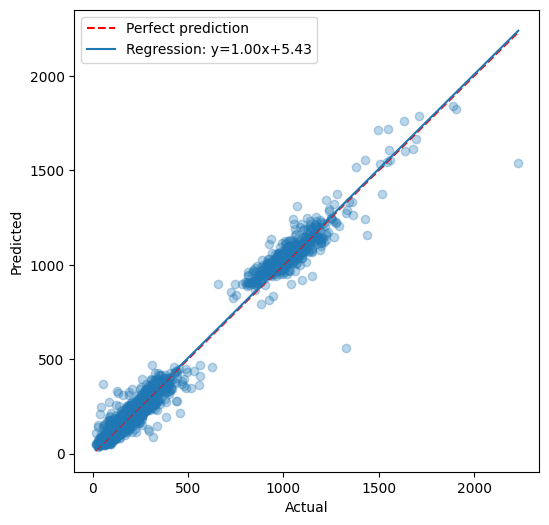

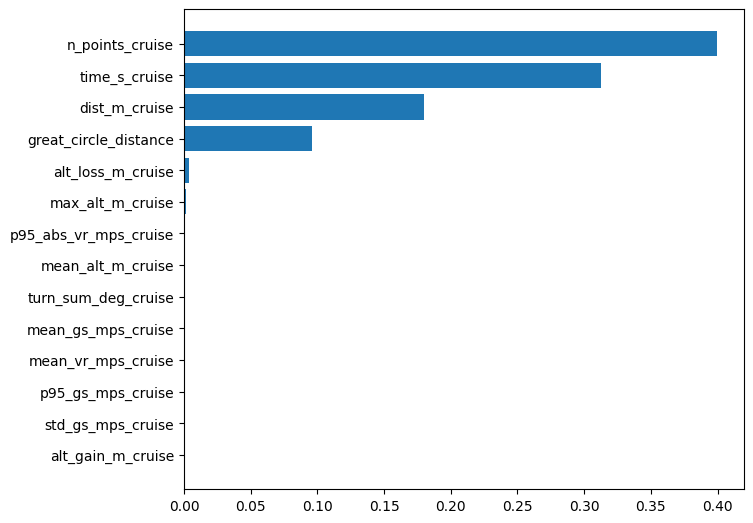

In [16]:
X_test_df = make_X(test)
run_regression_report(

    model=final_model,
    X_test=X_test_df,
    y_test=y_true,
    y_pred=y_pred,
    model_name="Cruise model"
)
